# 📊 Notebook 4: Statistical Visualization

**Topik:** Histogram, Correlation & Causation, Regplot, Statistical Category Variables (Boxplot), Grouping & Pivot Table

**Dataset:** Automobile (car specs & price) + EPL Goal Scorer

---

## 0. Setup & Buat Dataset Automobile

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Load EPL dataset
df_epl = pd.read_csv('epl_goalscorer_2021.csv')

# ==============================================================
# Buat dataset Automobile (simulasi dari materi)
# ==============================================================
np.random.seed(0)
n = 200

makes       = np.random.choice(['alfa-romeo','audi','bmw','chevrolet','dodge',
                                 'honda','mazda','mercedes-benz','mitsubishi',
                                 'nissan','porsche','toyota','volkswagen','volvo'], n)
body_styles = np.random.choice(['convertible','hatchback','sedan','wagon','hardtop'],
                                n, p=[0.05,0.30,0.40,0.15,0.10])
drive_wheels = np.random.choice(['fwd','rwd','4wd'], n, p=[0.55,0.35,0.10])
engine_size  = np.random.randint(70, 330, n)
peak_rpm     = np.random.randint(4200, 6600, n)
highway_mpg  = np.random.randint(15, 55, n)
wheel_base   = np.round(np.random.uniform(86, 115, n), 1)
bore         = np.round(np.random.uniform(2.5, 4.1, n), 2)
stroke       = np.round(np.random.uniform(2.5, 4.1, n), 2)

# Price berkorelasi positif dengan engine_size, negatif dengan highway_mpg
base_price = (engine_size * 80) + (wheel_base * 100) - (highway_mpg * 120)
noise      = np.random.normal(0, 2000, n)
price      = np.clip(base_price + noise, 5000, 50000).astype(int)

df = pd.DataFrame({
    'make'        : makes,
    'body-style'  : body_styles,
    'drive-wheels': drive_wheels,
    'wheel-base'  : wheel_base,
    'engine-size' : engine_size,
    'highway-mpg' : highway_mpg,
    'peak-rpm'    : peak_rpm,
    'bore'        : bore,
    'stroke'      : stroke,
    'price'       : price,
})

df.to_csv('automobile_sim.csv', index=False)
print(f'✅ Dataset Automobile: {df.shape}')
df.head()

✅ Dataset Automobile: (200, 10)


,make,body-style,drive-wheels,wheel-base,engine-size,highway-mpg,peak-rpm,bore,stroke,price
0,volkswagen,sedan,fwd,99.7,264,17,4899,2.80,3.13,30514
1,honda,hatchback,rwd,88.0,295,17,6377,2.67,2.67,29609
2,alfa-romeo,hatchback,rwd,113.4,210,34,6138,2.69,3.15,23476
3,chevrolet,hardtop,fwd,114.0,188,27,5508,3.07,2.97,19717
4,toyota,sedan,fwd,106.9,103,45,4648,2.51,3.29,11969


---
## 1. Histogram

**Kegunaan:** Memahami distribusi dari satu variabel numerik — menampilkan frekuensi kemunculan nilai dalam interval (bin) tertentu.

Sesuai materi: `DataFrame.hist()` dan `.plot(kind='hist')`

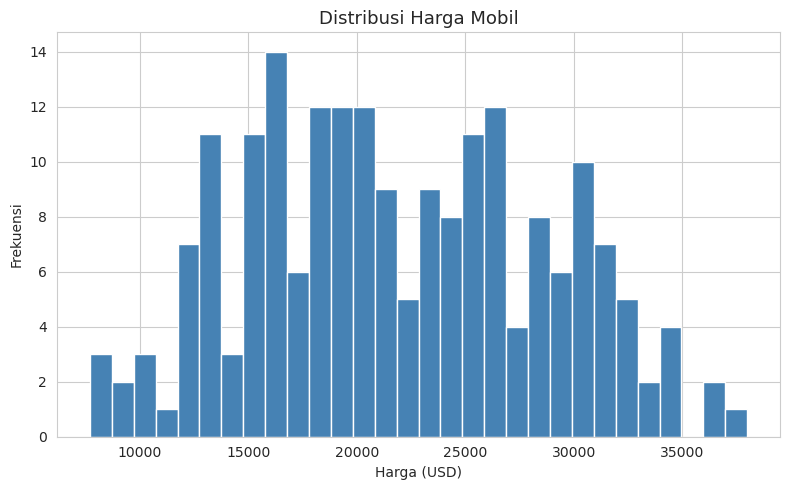


Distribusi harga: Mean=$21,889, Median=$21,353


In [2]:
# === Histogram 1: Distribusi harga mobil (dari materi) ===
df.hist(column='price', bins=30, color='steelblue', edgecolor='white', figsize=(8,5))
plt.xlabel('Harga (USD)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Harga Mobil', fontsize=13)
plt.tight_layout()
plt.savefig('plot_hist_price.png', bbox_inches='tight')
plt.show()
print(f'\nDistribusi harga: Mean=${df["price"].mean():,.0f}, Median=${df["price"].median():,.0f}')

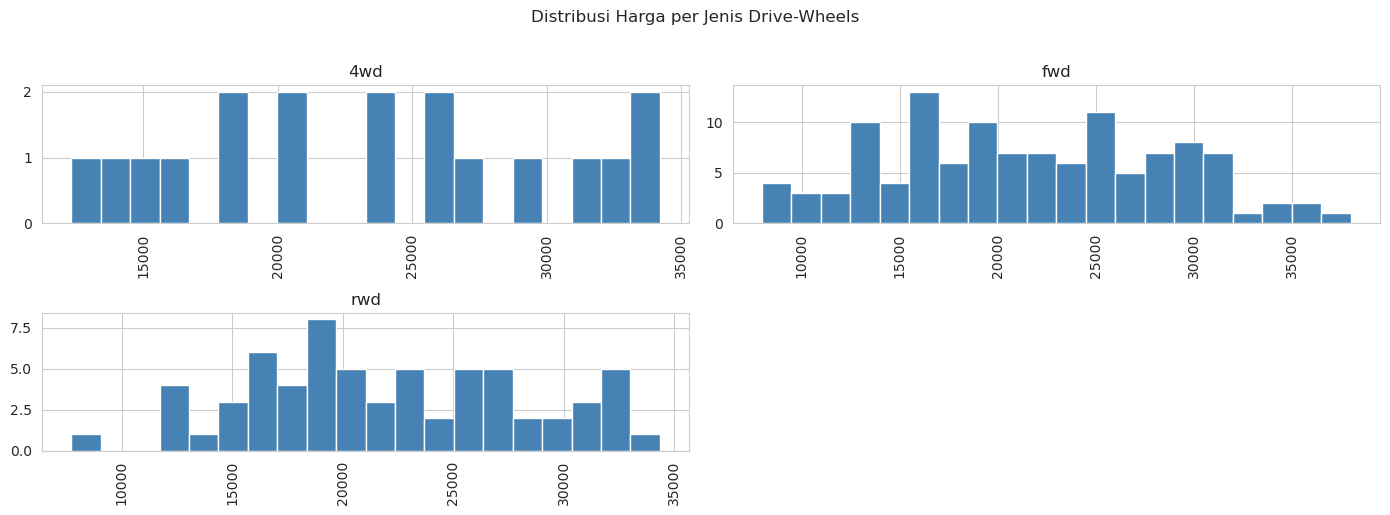

In [3]:
# === Histogram 2: Harga per drive-wheels (grouped) ===
df.hist(column='price', by='drive-wheels', bins=20,
        figsize=(14, 5), color='steelblue', edgecolor='white')
plt.suptitle('Distribusi Harga per Jenis Drive-Wheels', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plot_hist_price_by_drive.png', bbox_inches='tight')
plt.show()

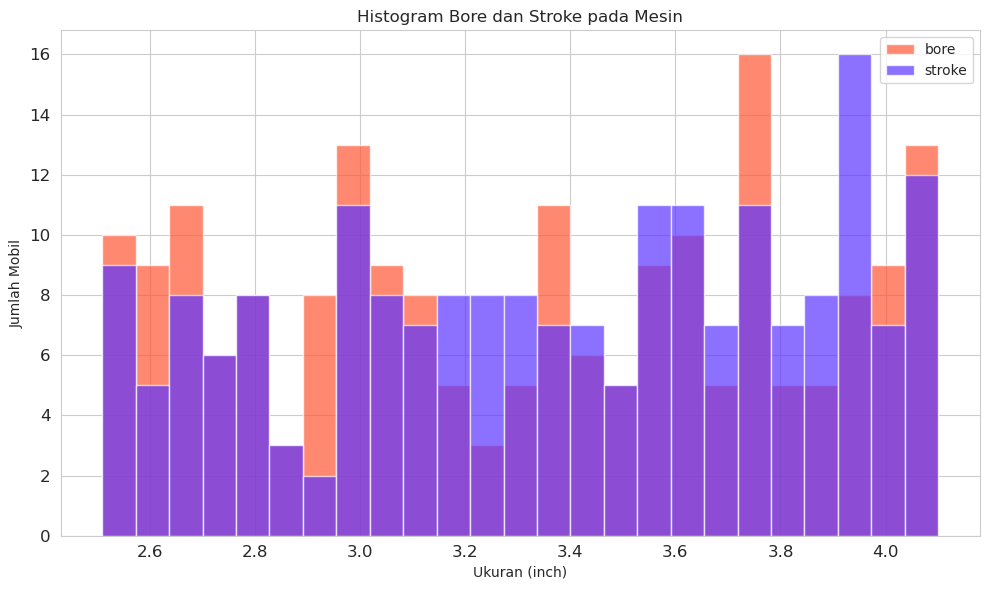

In [4]:
# === Histogram 3: Overlay 2 variabel dalam satu figure (bore vs stroke) ===
df[['bore','stroke']].plot(
    kind='hist', alpha=0.7, bins=25,
    title='Histogram Bore dan Stroke pada Mesin',
    figsize=(10, 6), fontsize=12,
    color=['#FF5733','#5C33FF'],
    edgecolor='white'
)
plt.xlabel('Ukuran (inch)')
plt.ylabel('Jumlah Mobil')
plt.tight_layout()
plt.savefig('plot_hist_bore_stroke.png', bbox_inches='tight')
plt.show()

---
## 2. Correlation & Causation

Sesuai materi:
- **Korelasi** = ukuran ketergantungan antara dua variabel (tidak berarti sebab-akibat)
- **Kausalitas** = hubungan sebab-akibat (butuh analisis lebih lanjut)

**Pearson Correlation Coefficient:**
- `+1` = korelasi positif sempurna
- `0`  = tidak ada korelasi linear
- `-1` = korelasi negatif sempurna

In [5]:
# Korelasi seluruh kolom numerik
print('=== Correlation Matrix (Pearson) ===')
corr_matrix = df.select_dtypes('number').corr()
corr_matrix

=== Correlation Matrix (Pearson) ===


,wheel-base,engine-size,highway-mpg,peak-rpm,bore,stroke,price
wheel-base,1.000000,0.094232,-0.029772,0.074891,-0.058313,0.005515,0.175919
engine-size,0.094232,1.000000,-0.102958,-0.051675,-0.007539,0.013405,0.928713
highway-mpg,-0.029772,-0.102958,1.000000,0.028550,0.173854,0.035288,-0.304631
peak-rpm,0.074891,-0.051675,0.028550,1.000000,0.102076,0.042411,-0.018842
bore,-0.058313,-0.007539,0.173854,0.102076,1.000000,0.073700,-0.050422
stroke,0.005515,0.013405,0.035288,0.042411,0.073700,1.000000,-0.007637
price,0.175919,0.928713,-0.304631,-0.018842,-0.050422,-0.007637,1.000000


In [6]:
# === Pearson Correlation + p-value (dari materi) ===
print('=== Pearson Correlation & P-Value: wheel-base vs price ===')
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print(f'Pearson Coefficient  : {pearson_coef:.6f}')
print(f'P-Value              : {p_value:.2e}')
print()
if p_value < 0.001:
    print('✅ Korelasi SANGAT SIGNIFIKAN secara statistik (p < 0.001)')
elif p_value < 0.05:
    print('✅ Korelasi SIGNIFIKAN secara statistik (p < 0.05)')
else:
    print('❌ Korelasi TIDAK SIGNIFIKAN (p > 0.05)')

=== Pearson Correlation & P-Value: wheel-base vs price ===
Pearson Coefficient  : 0.175919
P-Value              : 1.27e-02

✅ Korelasi SIGNIFIKAN secara statistik (p < 0.05)


In [7]:
# Korelasi semua kolom numerik terhadap price
print('=== Korelasi Semua Variabel terhadap Price ===')
corr_with_price = df.select_dtypes('number').corr()['price'].drop('price').sort_values(ascending=False)
for col, val in corr_with_price.items():
    sign = '📈 Positif' if val > 0.3 else ('📉 Negatif' if val < -0.3 else '➡️  Lemah')
    _, pv = stats.pearsonr(df[col].dropna(), df.loc[df[col].notna(), 'price'])
    sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'n.s.'))
    print(f'  {col:15s}: r={val:+.4f}  p={pv:.2e} {sig}  {sign}')

=== Korelasi Semua Variabel terhadap Price ===
  engine-size    : r=+0.9287  p=2.98e-87 ***  📈 Positif
  wheel-base     : r=+0.1759  p=1.27e-02 *  ➡️  Lemah
  stroke         : r=-0.0076  p=9.15e-01 n.s.  ➡️  Lemah
  peak-rpm       : r=-0.0188  p=7.91e-01 n.s.  ➡️  Lemah
  bore           : r=-0.0504  p=4.78e-01 n.s.  ➡️  Lemah
  highway-mpg    : r=-0.3046  p=1.16e-05 ***  📉 Negatif


---
## 3. Regplot (Seaborn)

**Kegunaan:** Scatter plot + garis regresi untuk memvisualisasikan hubungan linear antar variabel.

Sesuai materi: `sns.regplot()`

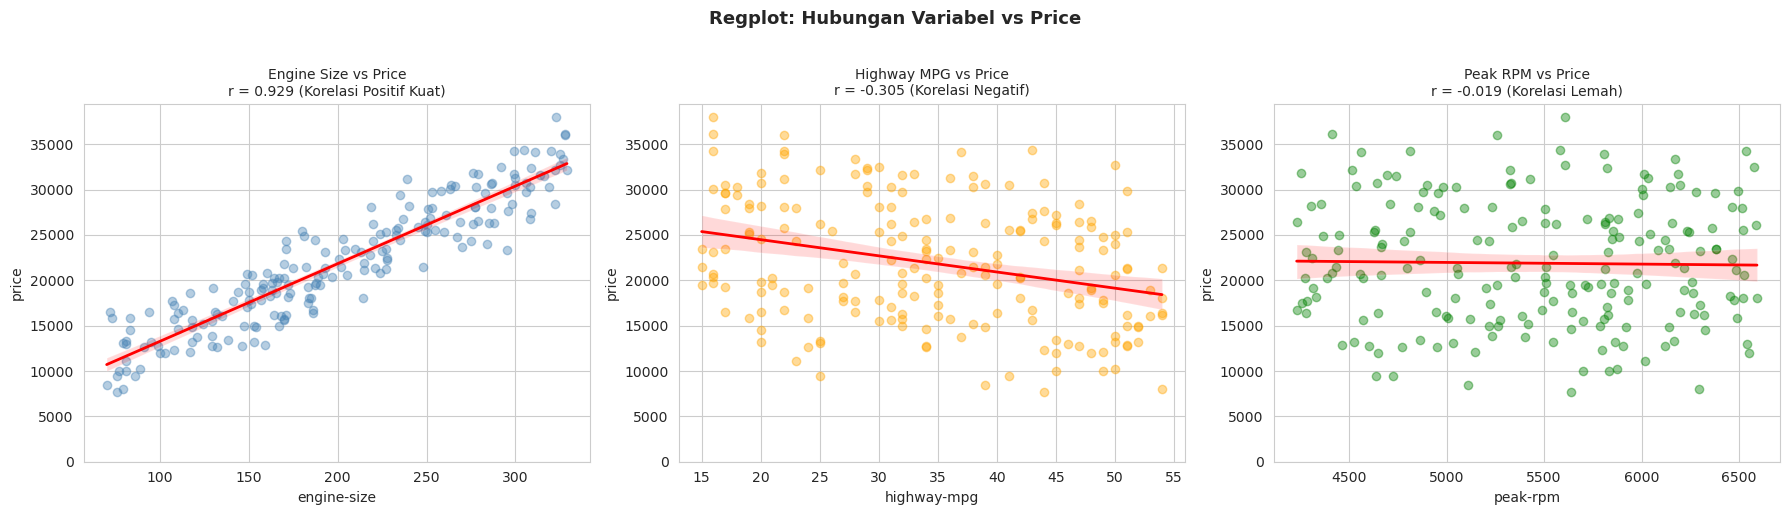


📊 Semakin curam garis regresi → korelasi semakin kuat


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# === Regplot 1: Engine-size vs Price (Korelasi Positif Kuat) ===
sns.regplot(x='engine-size', y='price', data=df, ax=axes[0],
            scatter_kws={'alpha':0.4, 'color':'steelblue'},
            line_kws={'color':'red', 'linewidth':2})
corr1 = df['engine-size'].corr(df['price'])
axes[0].set_title(f'Engine Size vs Price\nr = {corr1:.3f} (Korelasi Positif Kuat)', fontsize=10)
axes[0].set_ylim(0,)

# === Regplot 2: Highway-MPG vs Price (Korelasi Negatif) ===
sns.regplot(x='highway-mpg', y='price', data=df, ax=axes[1],
            scatter_kws={'alpha':0.4, 'color':'orange'},
            line_kws={'color':'red', 'linewidth':2})
corr2 = df['highway-mpg'].corr(df['price'])
axes[1].set_title(f'Highway MPG vs Price\nr = {corr2:.3f} (Korelasi Negatif)', fontsize=10)
axes[1].set_ylim(0,)

# === Regplot 3: Peak-RPM vs Price (Korelasi Lemah) ===
sns.regplot(x='peak-rpm', y='price', data=df, ax=axes[2],
            scatter_kws={'alpha':0.4, 'color':'green'},
            line_kws={'color':'red', 'linewidth':2})
corr3 = df['peak-rpm'].corr(df['price'])
axes[2].set_title(f'Peak RPM vs Price\nr = {corr3:.3f} (Korelasi Lemah)', fontsize=10)
axes[2].set_ylim(0,)

plt.suptitle('Regplot: Hubungan Variabel vs Price', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_regplot.png', bbox_inches='tight')
plt.show()
print('\n📊 Semakin curam garis regresi → korelasi semakin kuat')

---
## 4. Statistical Category Variables — Boxplot

**Kegunaan:** Visualisasi distribusi data per kategori sekaligus menampilkan Q1, Median, Q3, Whiskers, dan Outlier.

Sesuai materi: `sns.boxplot()`

**Anatomi Boxplot:**
```
        |        ← Max / Upper Fence
        ─
     ┌──┤        ← Q3 (75%)
     │  │        ← IQR
     ├──┤        ← Median (Q2)
     │  │
     └──┤        ← Q1 (25%)
        ─
        |        ← Min / Lower Fence
        ◆        ← Outlier
```

/tmp/ipykernel_178278/3208591266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body-style', y='price', data=df,


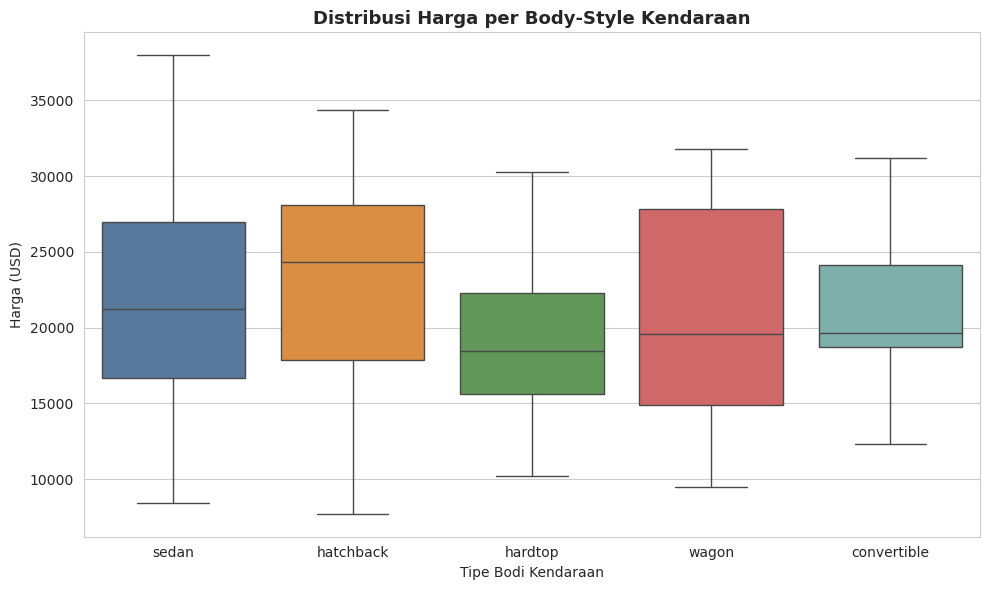

💡 Overlap besar antar kategori = body-style BUKAN prediktor harga yang baik


In [9]:
# === Boxplot 1: Price per Body-Style (dari materi) ===
plt.figure(figsize=(10, 6))
sns.boxplot(x='body-style', y='price', data=df,
            palette=['#4E79A7','#F28E2B','#59A14F','#E15759','#76B7B2'])
plt.title('Distribusi Harga per Body-Style Kendaraan', fontsize=13, fontweight='bold')
plt.xlabel('Tipe Bodi Kendaraan')
plt.ylabel('Harga (USD)')
plt.tight_layout()
plt.savefig('plot_box_body_style.png', bbox_inches='tight')
plt.show()
print('💡 Overlap besar antar kategori = body-style BUKAN prediktor harga yang baik')

/tmp/ipykernel_178278/3548293836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='drive-wheels', y='price', data=df,


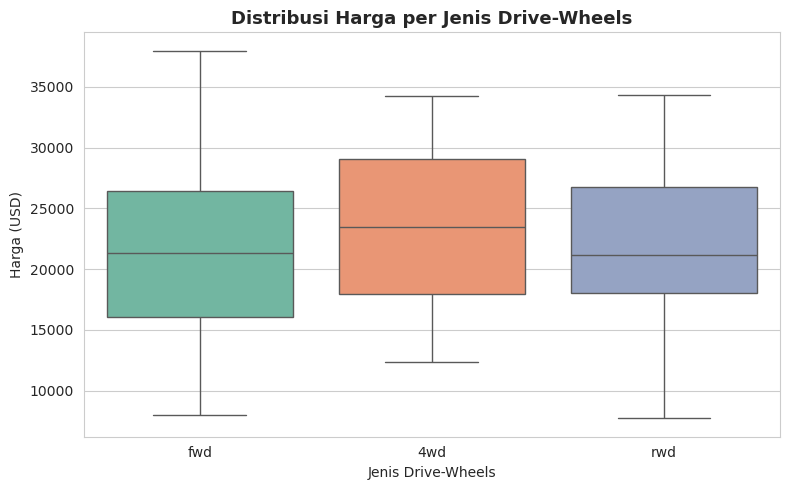


=== Rata-rata Harga per Drive-Wheels ===
drive-wheels
4wd    23452.833333
rwd    22114.830769
fwd    21523.641026
Name: price, dtype: float64


In [10]:
# === Boxplot 2: Price per Drive-Wheels ===
plt.figure(figsize=(8, 5))
sns.boxplot(x='drive-wheels', y='price', data=df,
            order=['fwd','4wd','rwd'],
            palette='Set2')
plt.title('Distribusi Harga per Jenis Drive-Wheels', fontsize=13, fontweight='bold')
plt.xlabel('Jenis Drive-Wheels')
plt.ylabel('Harga (USD)')
plt.tight_layout()
plt.savefig('plot_box_drive_wheels.png', bbox_inches='tight')
plt.show()

# Bandingkan mean price per drive-wheels
print('\n=== Rata-rata Harga per Drive-Wheels ===')
print(df.groupby('drive-wheels')['price'].mean().sort_values(ascending=False))

---
## 5. Grouping & Pivot Table

Sesuai materi: Mengelompokkan data menggunakan `groupby()` lalu mengubahnya menjadi pivot table dengan `pivot()`.

In [11]:
# Lihat kategori unik drive-wheels
print('=== Kategori Drive-Wheels ===')
print(df['drive-wheels'].unique())
print()

# === Groupby 1: Rata-rata harga per drive-wheels (dari materi) ===
df_group_one = df[['drive-wheels', 'body-style', 'price']]
df_group_one = df_group_one.groupby(['drive-wheels'], as_index=False).mean(numeric_only=True)
print('=== Rata-rata Harga per Drive-Wheels ===')
df_group_one

=== Kategori Drive-Wheels ===
['fwd' 'rwd' '4wd']

=== Rata-rata Harga per Drive-Wheels ===


,drive-wheels,price
0,4wd,23452.833333
1,fwd,21523.641026
2,rwd,22114.830769


In [12]:
# === Groupby 2: Group by 2 variabel (drive-wheels + body-style) ===
df_gptest = df[['drive-wheels', 'body-style', 'price']]
grouped_test1 = df_gptest.groupby(
    ['drive-wheels', 'body-style'], as_index=False
).mean(numeric_only=True)

print('=== Rata-rata Harga per Drive-Wheels + Body-Style ===')
grouped_test1

=== Rata-rata Harga per Drive-Wheels + Body-Style ===


,drive-wheels,body-style,price
0,4wd,convertible,12324.000000
1,4wd,hardtop,17094.500000
2,4wd,hatchback,27651.000000
3,4wd,sedan,26977.000000
4,4wd,wagon,21003.000000
5,fwd,convertible,21930.857143
6,fwd,hardtop,20544.416667
7,fwd,hatchback,22165.333333
8,fwd,sedan,21823.173077
9,fwd,wagon,20260.421053


In [13]:
# === Pivot Table dari hasil groupby ===
grouped_pivot = grouped_test1.pivot(
    index='drive-wheels',
    columns='body-style',
    values='price'
)
grouped_pivot = grouped_pivot.fillna(0)

print('=== Pivot Table: Drive-Wheels × Body-Style → Avg Price ===')
grouped_pivot

=== Pivot Table: Drive-Wheels × Body-Style → Avg Price ===


body-style,convertible,hardtop,hatchback,sedan,wagon
drive-wheels,,,,,
4wd,12324.000000,17094.500000,27651.000000,26977.000000,21003.000000
fwd,21930.857143,20544.416667,22165.333333,21823.173077,20260.421053
rwd,21732.000000,17255.250000,23346.730769,21154.720000,23637.000000


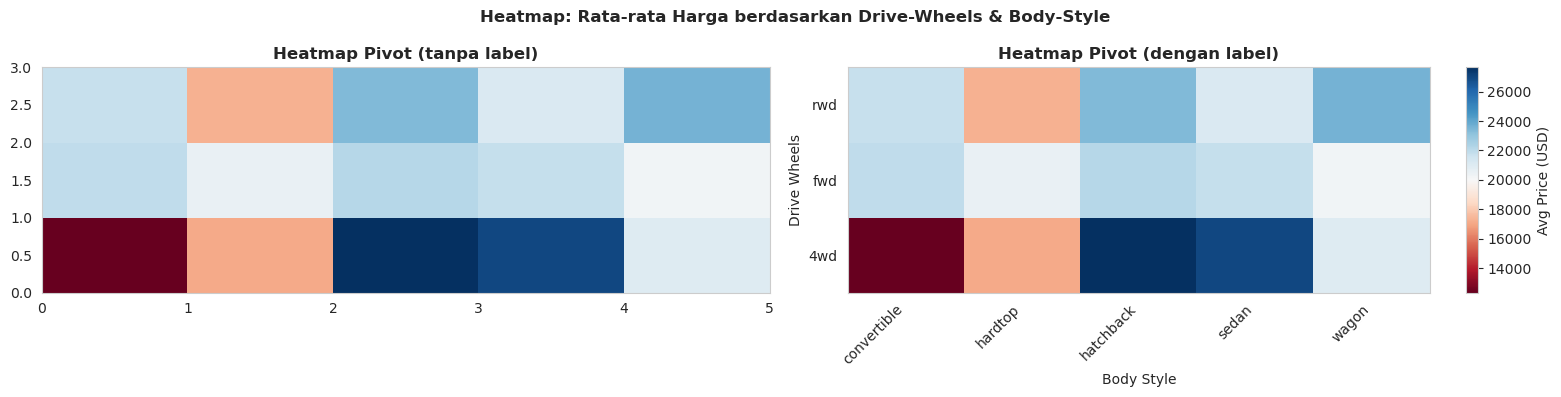

🔵 Biru gelap = harga tinggi | 🔴 Merah gelap = harga rendah


In [14]:
# === Heatmap dari Pivot Table (dari materi) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Tanpa label (raw)
axes[0].pcolor(grouped_pivot, cmap='RdBu')
axes[0].set_title('Heatmap Pivot (tanpa label)', fontweight='bold')

# Dengan label lengkap
im = axes[1].pcolor(grouped_pivot, cmap='RdBu')
row_labels = grouped_pivot.columns
col_labels = grouped_pivot.index
axes[1].set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
axes[1].set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)
axes[1].set_xticklabels(row_labels, minor=False, rotation=45, ha='right')
axes[1].set_yticklabels(col_labels, minor=False)
axes[1].set_xlabel('Body Style')
axes[1].set_ylabel('Drive Wheels')
axes[1].set_title('Heatmap Pivot (dengan label)', fontweight='bold')
fig.colorbar(im, ax=axes[1], label='Avg Price (USD)')

plt.suptitle('Heatmap: Rata-rata Harga berdasarkan Drive-Wheels & Body-Style',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_heatmap_pivot.png', bbox_inches='tight')
plt.show()
print('🔵 Biru gelap = harga tinggi | 🔴 Merah gelap = harga rendah')

---
## 6. Ringkasan

| Teknik | Fungsi | Metode |
|---|---|---|
| **Histogram** | Distribusi frekuensi satu variabel | `df.hist()` / `.plot(kind='hist')` |
| **Pearson Corr** | Korelasi linear dua variabel numerik | `df.corr()` / `stats.pearsonr()` |
| **Regplot** | Scatter + garis regresi | `sns.regplot()` |
| **Boxplot** | Distribusi variabel per kategori | `sns.boxplot()` |
| **Groupby** | Statistik per kelompok kategori | `df.groupby().mean()` |
| **Pivot Table** | Tabel silang 2 variabel kategorik | `.pivot()` |
| **Heatmap Pivot** | Visualisasi pivot table | `plt.pcolor()` / `sns.heatmap()` |

> ⚠️ **Ingat:** Korelasi ≠ Kausalitas! Dua variabel yang berkorelasi tinggi belum tentu saling menyebabkan.